In [1]:
%pip install networkx[default]

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)

   ---------------------------------------- 0/2 [contourpy]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 

{'current': 'F', 'visited': {'F', 'B', 'D', 'C', 'E', 'A'}, 'dist': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 5, 'F': 5}}


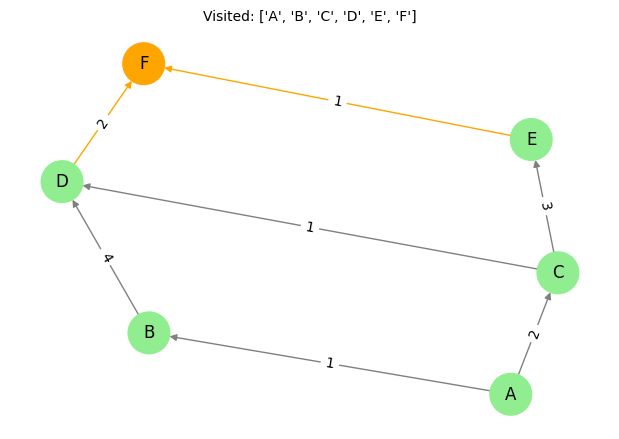

In [2]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time


def draw_graph(G, pos, visited=None, current=None, queue=None, dist=None):
    visited = visited or set()
    node_colors = []
    for node in G.nodes():
        if node == current:
            node_colors.append('orange')
        elif node in visited:
            node_colors.append('lightgreen')
        else:
            node_colors.append('lightgray')

    edge_colors = []
    for u, v in G.edges():
        if current is not None and (u == current or v == current):
            edge_colors.append('orange')
        else:
            edge_colors.append('gray')

    plt.figure(figsize=(6, 4))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, node_size=900, font_size=12)

    if dist is not None:
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    title_lines = []
    if queue is not None:
        title_lines.append(f"Queue: {queue}")
    if visited:
        title_lines.append(f"Visited: {sorted(visited)}")
    plt.title('\n'.join(title_lines), fontsize=10)
    plt.axis('off')
    display(plt.gcf())
    plt.close()


def bfs_steps(G, start):
    visited = set()
    queue = [start]
    steps = []

    while queue:
        current = queue.pop(0)
        if current in visited:
            continue
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'queue': list(queue)})

        for neighbor in sorted(G.neighbors(current)):
            if neighbor not in visited and neighbor not in queue:
                queue.append(neighbor)

    return steps


def dfs_steps(G, start):
    visited = set()
    stack = [start]
    steps = []

    while stack:
        current = stack.pop()
        if current in visited:
            continue
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'stack': list(stack)})

        for neighbor in sorted(G.neighbors(current), reverse=True):
            if neighbor not in visited:
                stack.append(neighbor)

    return steps


def dijkstra_steps(G, start):
    dist = {node: float('inf') for node in G.nodes()}
    dist[start] = 0
    visited = set()
    steps = []

    while len(visited) < len(G.nodes()):
        unvisited_nodes = {node: dist[node] for node in G.nodes() if node not in visited}
        if not unvisited_nodes:
            break

        current = min(unvisited_nodes, key=unvisited_nodes.get)
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'dist': dict(dist)})

        for neighbor in G.neighbors(current):
            new_dist = dist[current] + G[current][neighbor].get('weight', 1)
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist

    return steps


# Build a small graph to explore
G = nx.DiGraph()
G.add_weighted_edges_from([
    ('A', 'B', 1),
    ('A', 'C', 2),
    ('B', 'D', 4),
    ('C', 'D', 1),
    ('C', 'E', 3),
    ('D', 'F', 2),
    ('E', 'F', 1),
])

pos = nx.spring_layout(G, seed=42)

print('Graph nodes:', G.nodes())
print('Graph edges with weights:', list(G.edges(data='weight')))

# Visualize the base graph
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=900, font_size=12)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()

print('\nBFS steps:')
for step in bfs_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], queue=step['queue'])
    time.sleep(0.7)

print('\nDFS steps:')
for step in dfs_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], queue=step['stack'])
    time.sleep(0.7)

print('\nDijkstra steps:')
for step in dijkstra_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], dist=step['dist'])
    time.sleep(0.7)

## Priority Queue (Bubble Up Method)

A binary heap stores the priority queue inside a Python list. The list becomes a tree by using indices:

- root index = 0
- left child = 2 * i + 1
- right child = 2 * i + 2
- parent = (i - 1) // 2

That means the heap is a complete binary tree, but stored in a flat list.

### Why bubble-up exists
When a new value is added, it goes at the end of the list. This keeps the tree shape correct, but it may break the heap order.

In a min-heap, each parent must be <= each child. The newly inserted value is the only node that can violate that rule because the rest of the heap was already valid.

So bubble-up does this:

1. append the new value at the end
2. compare the inserted node with its parent
3. if the child is smaller than the parent, swap them
4. repeat from the new parent position
5. stop when the node reaches the root or when the parent is smaller

This is called bubble-up because the new value "bubbles" upward until the heap order is restored.

### How to read the visualization
- Orange node: the current node being checked or moved
- Yellow node: its parent
- Blue nodes: other heap nodes
- The text at the bottom shows the heap list as `[index:value]`
- The step title explains the action being performed

### Example sequence

Start with an empty heap: `[]`

- insert `5` → `[5]`
- insert `3` → `[5, 3]` → compare `3` with parent `5` → swap → `[3, 5]`
- insert `8` → `[3, 5, 8]` → compare `8` with parent `3` → no swap
- insert `1` → `[3, 5, 8, 1]` → compare `1` with parent `5` → swap → `[3, 1, 8, 5]` → compare `1` with parent `3` → swap → `[1, 3, 8, 5]`

Run the next cell to see these steps animated and annotated with node colors, parent relationships, and list positions.

In [10]:
class MinHeap:
    def __init__(self):
        self.heap = []

    def parent(self, index):
        return (index - 1) // 2

    def left(self, index):
        return 2 * index + 1

    def right(self, index):
        return 2 * index + 2

    def bubble_up(self, index):
        while index > 0:
            parent_index = self.parent(index)
            if self.heap[index] < self.heap[parent_index]:
                self.heap[index], self.heap[parent_index] = (
                    self.heap[parent_index],
                    self.heap[index],
                )
                index = parent_index
            else:
                break

    def push(self, value):
        self.heap.append(value)
        self.bubble_up(len(self.heap) - 1)

    def pop(self):
        if not self.heap:
            raise IndexError("pop from empty heap")

        root = self.heap[0]
        last = self.heap.pop()
        if self.heap:
            self.heap[0] = last
            self.bubble_down(0)
        return root

    def bubble_down(self, index):
        size = len(self.heap)
        while True:
            left = self.left(index)
            right = self.right(index)
            smallest = index

            if left < size and self.heap[left] < self.heap[smallest]:
                smallest = left
            if right < size and self.heap[right] < self.heap[smallest]:
                smallest = right

            if smallest == index:
                break

            self.heap[index], self.heap[smallest] = (
                self.heap[smallest],
                self.heap[index],
            )
            index = smallest

Done inserting 6   |   heap = [1, 3, 8, 5, 6]


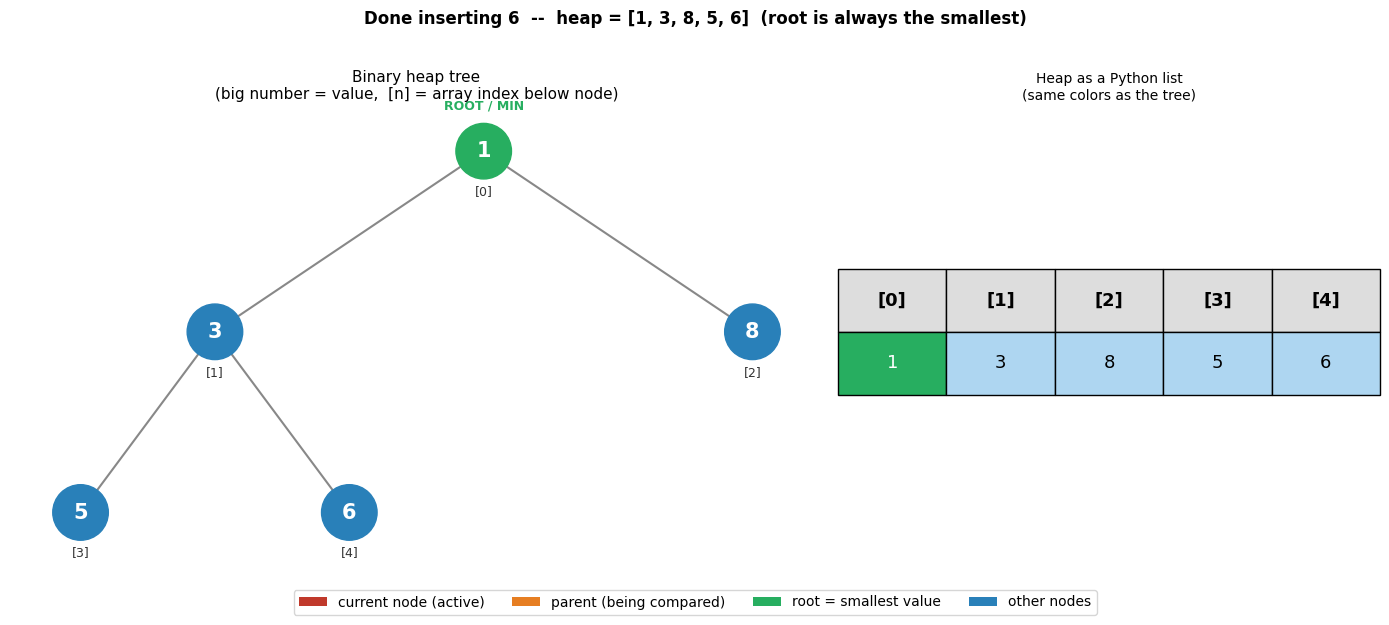

In [8]:

import math
from matplotlib.patches import Patch

# Color scheme — distinct and easy to tell apart
COLOR_CURRENT = "#c0392b"   # red:   the node we just inserted or are moving
COLOR_PARENT  = "#e67e22"   # orange: the parent we are comparing against
COLOR_ROOT    = "#27ae60"   # green:  always the root (smallest value)
COLOR_DEFAULT = "#2980b9"   # blue:   all other nodes


def heap_positions(n):
    """
    Place heap nodes in a proper symmetric binary tree shape.

    How a heap maps to tree levels:
      Level 0 -> index 0          (root)
      Level 1 -> indices 1, 2
      Level 2 -> indices 3, 4, 5, 6
      Level k -> indices (2^k - 1) to (2^(k+1) - 2)

    The trick: level = int(log2(i + 1))  works for all i >= 0.
    """
    if n == 0:
        return {}
    positions = {}
    max_level = int(math.log2(n)) if n > 1 else 0
    full_width = 2 ** max_level   # widest row -- sets horizontal scale

    for i in range(n):
        level = int(math.log2(i + 1)) if i > 0 else 0
        first_at_level = (2 ** level) - 1         # index of leftmost node at this level
        index_in_level = i - first_at_level        # 0-based position within this level
        capacity = 2 ** level                      # max nodes possible at this level
        spacing = full_width / capacity            # horizontal gap between nodes
        x = (index_in_level + 0.5) * spacing - full_width / 2
        positions[i] = (x, -level * 1.5)          # y goes down with each level

    return positions


def build_heap_graph(heap):
    G = nx.DiGraph()
    for idx in range(len(heap)):
        G.add_node(idx)
        if idx > 0:
            parent = (idx - 1) // 2   # parent formula for any heap index
            G.add_edge(parent, idx)
    return G


def draw_heap(heap, current_index=None, parent_index=None, action=None):
    if not heap:
        return

    G = build_heap_graph(heap)
    pos = heap_positions(len(heap))

    # Show only the value inside the node (index shown below in a separate label)
    labels = {idx: str(heap[idx]) for idx in range(len(heap))}

    node_colors = []
    for idx in G.nodes():
        if idx == current_index:
            node_colors.append(COLOR_CURRENT)
        elif idx == parent_index:
            node_colors.append(COLOR_PARENT)
        elif idx == 0:
            node_colors.append(COLOR_ROOT)
        else:
            node_colors.append(COLOR_DEFAULT)

    edge_colors = [
        "#c0392b" if (u == parent_index and v == current_index) else "#888888"
        for u, v in G.edges()
    ]
    edge_widths = [
        3.5 if (u == parent_index and v == current_index) else 1.5
        for u, v in G.edges()
    ]

    fig, (ax_tree, ax_array) = plt.subplots(
        1, 2, figsize=(14, 6),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # ── Left: tree ──────────────────────────────────────────────────────────
    nx.draw(
        G, pos,
        labels=labels,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        width=edge_widths,
        node_size=1600,
        font_size=15,
        font_weight="bold",
        font_color="white",
        arrows=False,
        ax=ax_tree,
    )

    # Array index shown as small label below each node
    for idx, (x, y) in pos.items():
        ax_tree.text(x, y - 0.28, f"[{idx}]",
                     ha="center", va="top", fontsize=9, color="#333333")

    # ROOT label above root node
    if 0 in pos:
        rx, ry = pos[0]
        ax_tree.text(rx, ry + 0.32, "ROOT / MIN",
                     ha="center", va="bottom", fontsize=9,
                     color=COLOR_ROOT, fontweight="bold")

    ax_tree.set_title(
        "Binary heap tree\n(big number = value,  [n] = array index below node)",
        fontsize=11, pad=10
    )
    ax_tree.axis("off")

    # ── Right: array ────────────────────────────────────────────────────────
    n = len(heap)
    table = ax_array.table(
        cellText=[[str(v) for v in heap]],
        colLabels=[f"[{i}]" for i in range(n)],
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1, 4)

    for i in range(n):
        header = table[0, i]
        header.set_facecolor("#dddddd")
        header.set_text_props(fontweight="bold")

        cell = table[1, i]   # data row
        if i == current_index:
            cell.set_facecolor(COLOR_CURRENT)
            cell.set_text_props(color="white", fontweight="bold")
        elif i == parent_index:
            cell.set_facecolor(COLOR_PARENT)
            cell.set_text_props(fontweight="bold")
        elif i == 0:
            cell.set_facecolor(COLOR_ROOT)
            cell.set_text_props(color="white")
        else:
            cell.set_facecolor("#aed6f1")

    ax_array.axis("off")
    ax_array.set_title(
        "Heap as a Python list\n(same colors as the tree)",
        fontsize=10, pad=10
    )

    # ── Legend ──────────────────────────────────────────────────────────────
    legend_items = [
        Patch(facecolor=COLOR_CURRENT, label="current node (active)"),
        Patch(facecolor=COLOR_PARENT,  label="parent (being compared)"),
        Patch(facecolor=COLOR_ROOT,    label="root = smallest value"),
        Patch(facecolor=COLOR_DEFAULT, label="other nodes"),
    ]
    fig.legend(handles=legend_items, loc="lower center", ncol=4,
               fontsize=10, bbox_to_anchor=(0.5, 0.0), fancybox=True)

    step_title = action if action else f"Heap state: {heap}"
    fig.suptitle(step_title, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 1.0])
    display(fig)
    plt.close(fig)


def bubble_up_trace(heap):
    steps = []
    index = len(heap) - 1
    while index > 0:
        parent = (index - 1) // 2
        steps.append({
            "action": "compare",
            "current_index": index,
            "parent_index": parent,
            "heap": list(heap),
        })
        if heap[index] < heap[parent]:
            heap[index], heap[parent] = heap[parent], heap[index]
            steps.append({
                "action": "swap",
                "current_index": parent,
                "parent_index": (parent - 1) // 2 if parent > 0 else None,
                "heap": list(heap),
            })
            index = parent
        else:
            break
    return steps


def visualize_push_sequence(values, delay=1.2):
    heap = []
    for value in values:
        heap.append(value)
        msg = f"heap.append({value})  ->  new node at index {len(heap)-1}  |  heap = {heap}"
        clear_output(wait=True)
        print(msg)
        draw_heap(
            heap, current_index=len(heap) - 1,
            action=f"1. Append {value} at index {len(heap)-1} — bubble-up may be needed"
        )
        time.sleep(delay)

        steps = bubble_up_trace(heap)
        if not steps:
            print(f"  No bubble-up needed (only 1 node, or already in order)")

        for step in steps:
            clear_output(wait=True)
            ci = step["current_index"]
            pi = step["parent_index"]
            h  = step["heap"]

            if step["action"] == "compare":
                verdict = "SWAP needed  (child < parent)" if h[ci] < h[pi] else "no swap  (already in order)"
                msg = f"2. Compare:  child heap[{ci}] = {h[ci]}   vs   parent heap[{pi}] = {h[pi]}   ->  {verdict}"
            else:
                msg = f"3. SWAP up   {h[ci]} moved up to index {ci}   |   heap = {h}"

            print(msg)
            draw_heap(h, current_index=ci, parent_index=pi, action=msg)
            time.sleep(delay)

        clear_output(wait=True)
        print(f"Done inserting {value}   |   heap = {heap}")
        draw_heap(
            heap,
            action=f"Done inserting {value}  --  heap = {heap}  (root is always the smallest)"
        )
        time.sleep(delay)


visualize_push_sequence([5, 3, 8, 1, 6], delay=1.2)



## Why does the heap array look "out of order"?

The array `[1, 3, 8, 5, 6]` is a **valid min-heap** — but it is NOT a sorted array.

A heap only enforces one rule:
> **Every parent must be ≤ its children.**

It says *nothing* about siblings. `8` can legally sit next to `3` even though `8 > 3`, because they are siblings — neither is the other's parent.

Here is the tree from our example:

```
          1        ← index [0]  (root / minimum)
        /   \
       3     8     ← index [1] and [2]   (children of root)
      / \
     5   6         ← index [3] and [4]   (children of 3)
```

Check the heap rule at every node:
- `1 ≤ 3` ✓ and `1 ≤ 8` ✓
- `3 ≤ 5` ✓ and `3 ≤ 6` ✓
- `8` has no children — no rule to check

Why did `8` end up next to `3` instead of lower?  
When `8` was inserted it appended at index 2. Its parent was index 0 (value `1`). Since `8 > 1`, no swap was needed. `8` stayed right there.

The heap's superpower is **not sorting** — it is guaranteeing that `heap[0]` is ALWAYS the smallest element, in O(log n) per insert/remove. That is exactly what a priority queue needs.

---

## Priority Queue

A **priority queue** gives you items in priority order no matter what order you inserted them. You push tasks with a priority number, and `pop()` always returns the most urgent one (lowest number = highest priority).

The min-heap we already built IS a priority queue. Push `(priority, task)` tuples — Python compares tuples left to right, so the lowest priority number always bubbles to the top.


In [11]:

# ── Priority Queue demo using our MinHeap ───────────────────────────────────
#
# We push (priority_number, task_name) tuples.
# Python compares tuples left-to-right, so the LOWEST number wins.
# heap[0] is always (lowest_priority_number, its_task).

heap = MinHeap()

tasks = [
    (3, "Send weekly report"),
    (1, "Fix production crash"),   # highest priority
    (5, "Update docs"),
    (2, "Review pull request"),
    (4, "Refactor login module"),
]

print("=== Pushing tasks into the priority queue ===\n")
for priority, name in tasks:
    heap.push((priority, name))
    print(f"  push priority={priority}  task='{name}'   →  heap[0] = {heap.heap[0]}")

print("\n=== Popping tasks (highest priority first) ===\n")
while heap.heap:
    priority, name = heap.pop()
    print(f"  pop  →  priority={priority}  task='{name}'")

# ── Same thing using Python's built-in heapq ─────────────────────────────────
import heapq

print("\n=== Same result using Python's built-in heapq ===\n")
pq = []
for priority, name in tasks:
    heapq.heappush(pq, (priority, name))
    print(f"  heappush priority={priority}  task='{name}'   →  pq[0] = {pq[0]}")

print()
while pq:
    priority, name = heapq.heappop(pq)
    print(f"  heappop  →  priority={priority}  task='{name}'")


=== Pushing tasks into the priority queue ===

  push priority=3  task='Send weekly report'   →  heap[0] = (3, 'Send weekly report')
  push priority=1  task='Fix production crash'   →  heap[0] = (1, 'Fix production crash')
  push priority=5  task='Update docs'   →  heap[0] = (1, 'Fix production crash')
  push priority=2  task='Review pull request'   →  heap[0] = (1, 'Fix production crash')
  push priority=4  task='Refactor login module'   →  heap[0] = (1, 'Fix production crash')

=== Popping tasks (highest priority first) ===

  pop  →  priority=1  task='Fix production crash'
  pop  →  priority=2  task='Review pull request'
  pop  →  priority=3  task='Send weekly report'
  pop  →  priority=4  task='Refactor login module'
  pop  →  priority=5  task='Update docs'

=== Same result using Python's built-in heapq ===

  heappush priority=3  task='Send weekly report'   →  pq[0] = (3, 'Send weekly report')
  heappush priority=1  task='Fix production crash'   →  pq[0] = (1, 'Fix production cras